# 1. Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 2. Load Dataset

In [3]:
df = pd.read_csv('../data/raw/dirty_banking_transactions.csv')

# 3. Initial Data Analysis

In [4]:
df.head()

,Transaction_ID,Customer_ID,Account_Number,Transaction_Date,Transaction_Time,Transaction_Type,Transaction_Amount,Currency,Account_Balance,Merchant_Name,Merchant_Category,City,State,Country,Channel,Device_Type,Branch_Code,Customer_Age,Customer_Gender,Fraud_Flag
0,TXN00422668,CUST039661,ACC021003,21/05/2023,22:32:31,Debit,1270.7,INR,423630.82,Flipkart,<div>Retail</div>,Kolkata,West Bengal,India,POS Terminal,ATM Machine,BR065,44,Female,No
1,TXN00327432,CUST015485,ACC003812,2024-09-22,10:46:07,Debit,3620.53,INR,16311938.05,MakeMyTrip,Travel,Hyderabad,Telangana,India,Net Banking,iOS,BR049,38,Male,No
2,TXN00199316,CUST008430,ACC001386,2024-02-20,07:16:49,Debit,630.78,INR,26270.21,DMart,Grocery,Ahmedabad,Gujarat,India,POS Terminal,ATM Machine,BR050,66,Female,0
3,TXN00135198,CUST018867,ACC023753,2025-03-14,19:41:52,debit,89.21,INR,3672.39,Uber,Transport,Chennai,Tamil Nadu,India,ATM,Android,BR087,24,Male,No
4,TXN00361424,CUST009571,ACC010182,2025-06-16,00:51:31,Credit,429.69,INR,68722.57,Flipkart,NaN,Delhi,Delhi,India,POS Terminal,iOS,BR052,50,Female,No


In [5]:
df.tail()

,Transaction_ID,Customer_ID,Account_Number,Transaction_Date,Transaction_Time,Transaction_Type,Transaction_Amount,Currency,Account_Balance,Merchant_Name,Merchant_Category,City,State,Country,Channel,Device_Type,Branch_Code,Customer_Age,Customer_Gender,Fraud_Flag
510495,TXN00208880,CUST020644,ACC030246,2025-05-23,14:15:27,Credit,70235.98 INR,INR,52118.93,Flipkart,NaN,Hyderabad,Telangana,India,POS Terminal,iOS,BR056,58,Female,No
510496,TXN00491861,CUST032681,ACC023838,2024-03-17,13:35:16,DEBIT,$5.06,USD,57121.52,Amazon,Electronics,Ahmedabad,Gujarat,India,Net Banking,MacOS,BR019,51,Male,No
510497,TXN00366036,CUST032017,ACC015801,2024-01-17,16:34:42,Debit,1258.52,INR,3110.59,Apollo Pharmacy,Healthcare,Ahmedabad,Gujarat,India,Net Banking,iOS,BR057,58,Female,No
510498,TXN00455868,CUST013315,ACC024418,2024-12-31,01:25:16,Debit,1926.4,INR,11351.96,MakeMyTrip,Travel,Kolkata,West Bengal,India,ATM,Windows Desktop,BR048,37,Male,No
510499,TXN00069048,CUST021961,ACC013890,2024-07-11,14:42:56,Debit,480.0,INR,150466.80,DMart,Grocery,Kolkata,West Bengal,IND,Net Banking,ATM Machine,BR079,41,Female,No


In [6]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 510500 entries, 0 to 510499
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Transaction_ID      510500 non-null  str    
 1   Customer_ID         510500 non-null  str    
 2   Account_Number      510500 non-null  str    
 3   Transaction_Date    510500 non-null  str    
 4   Transaction_Time    510500 non-null  str    
 5   Transaction_Type    510500 non-null  str    
 6   Transaction_Amount  510500 non-null  str    
 7   Currency            510500 non-null  str    
 8   Account_Balance     510500 non-null  float64
 9   Merchant_Name       464437 non-null  str    
 10  Merchant_Category   464455 non-null  str    
 11  City                510500 non-null  str    
 12  State               510500 non-null  str    
 13  Country             510500 non-null  str    
 14  Channel             510500 non-null  str    
 15  Device_Type         454324 non-null  str    


In [7]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Account_Number', 'Transaction_Date',
       'Transaction_Time', 'Transaction_Type', 'Transaction_Amount',
       'Currency', 'Account_Balance', 'Merchant_Name', 'Merchant_Category',
       'City', 'State', 'Country', 'Channel', 'Device_Type', 'Branch_Code',
       'Customer_Age', 'Customer_Gender', 'Fraud_Flag'],
      dtype='str')

In [8]:
print(df.describe()) 

       Account_Balance
count     5.105000e+05
mean      6.076394e+06
std       1.799342e+08
min      -1.437058e+07
25%       2.191006e+04
50%       6.005207e+04
75%       1.649323e+05
max       5.500000e+09


In [9]:
print(df.describe(include='O')) # Summary of categorical columns

/var/folders/0m/s5flg_7943n1ftf1fzyctg1c0000gn/T/ipykernel_22132/1436372942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='O')) # Summary of categorical columns


       Transaction_ID       Customer_ID     Account_Number Transaction_Date  \
count          510500            510500             510500           510500   
unique         500500             40001              40001             4381   
top       TXN00106380  CUST_NONEXISTENT  INVALID_ACC_#####       2028-08-12   
freq                2              2498               2586             1030   

       Transaction_Time Transaction_Type Transaction_Amount Currency  \
count            510500           510500             510500   510500   
unique            86142                8             315825        4   
top            18:42:22            Debit                0.0      INR   
freq                 18           314384               2444   492606   

           Merchant_Name Merchant_Category     City        State Country  \
count             464437            464455   510500       510500  510500   
unique                60                18       12           10       4   
top     Relianc

# 4. Data Quality Assessment

In [10]:
# Checking missing values

missing = df.isnull().sum()
missing

Transaction_ID            0
Customer_ID               0
Account_Number            0
Transaction_Date          0
Transaction_Time          0
Transaction_Type          0
Transaction_Amount        0
Currency                  0
Account_Balance           0
Merchant_Name         46063
Merchant_Category     46045
City                      0
State                     0
Country                   0
Channel                   0
Device_Type           56176
Branch_Code           40294
Customer_Age          51032
Customer_Gender           0
Fraud_Flag                0
dtype: int64

In [11]:
missing_percentage = (missing / len(df)) * 100
missing_percentage.sort_values(ascending=False)

Device_Type           11.004114
Customer_Age           9.996474
Merchant_Name          9.023115
Merchant_Category      9.019589
Branch_Code            7.893046
City                   0.000000
Customer_Gender        0.000000
Channel                0.000000
Country                0.000000
State                  0.000000
Transaction_ID         0.000000
Customer_ID            0.000000
Account_Balance        0.000000
Currency               0.000000
Transaction_Amount     0.000000
Transaction_Type       0.000000
Transaction_Time       0.000000
Transaction_Date       0.000000
Account_Number         0.000000
Fraud_Flag             0.000000
dtype: float64

In [12]:
# Checking Duplicates

df.duplicated().sum()

np.int64(10000)

In [13]:
df[df.duplicated()]

,Transaction_ID,Customer_ID,Account_Number,Transaction_Date,Transaction_Time,Transaction_Type,Transaction_Amount,Currency,Account_Balance,Merchant_Name,Merchant_Category,City,State,Country,Channel,Device_Type,Branch_Code,Customer_Age,Customer_Gender,Fraud_Flag
6315,TXN00259016,CUST003212,ACC021658,2024-04-25,18:23:56,Debit,1366.98,INR,80134.17,DMart,Grocery,Ahmedabad,Gujarat,IND,Mobile App,ATM Machine,BR056,44,Female,FALSE
8043,TXN00176497,CUST001257,ACC035194,2025-05-12,05:25:00,Debit,2580.08,INR,2489.09,Apollo Pharmacy,Healthcare,Kolkata,West Bengal,India,Mobile App,NaN,BR093,45,Male,No
15312,TXN00194193,CUST023949,ACC023224,2024-07-16,11:45:00,Debit,150.4,INR,4832.94,Reliance Digital,Electronics,Bengaluru,Karnataka,India,Mobile App,Android,BR028,62,Female,Yes
15981,TXN00300744,CUST000302,ACC006590,2024-03-29,04:43:16,Debit,1935.37,INR,65620.32,Reliance Digital,Electronics,Pune,Maharashtra,India,ATM,MacOS,BR027,24,Female,No
17348,TXN00476861,CUST036600,ACC032450,2023-05-29,21:03:14,Debit,535.64,INR,801244.50,Reliance Digital,Electronics,Bengaluru,Karnataka,India,POS Terminal,NaN,BR055,22,Male,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510353,TXN00383221,CUST015907,ACC009043,2025-02-13,22:31:12,Debit,$35.40,USD,259549.24,Reliance Digital,Electronics,Delhi,Delhi,India,ATM,ATM Machine,BR052,57,Female,No
510356,TXN00231541,CUST031549,ACC000792,"December 10, 2024",08:08:05,Debit,1437.54,INR,63166.54,Flipkart,NaN,Pune,Maharashtra,India,Net Banking,MacOS,NaN,52,Female,0
510387,TXN00108022,CUST038933,ACC010171,2024-01-31,12:11:19,Credit,30.03,INR,5436.08,Flipkart,Retail,Kolkata,West Bengal,India,ATM,iOS,BR033,NaN,Female,No
510458,TXN00267155,CUST002111,ACC032867,"December 15, 2024",10:56:02,Debit,19070.92,INR,27317.31,Netflix,Entertainment,Kolkata,West Bengal,India,POS Terminal,MacOS,BR051,55,Male,No


In [14]:
df[df['Transaction_ID'] == 'TXN00259016'] # Checking for exact duplicate rows

,Transaction_ID,Customer_ID,Account_Number,Transaction_Date,Transaction_Time,Transaction_Type,Transaction_Amount,Currency,Account_Balance,Merchant_Name,Merchant_Category,City,State,Country,Channel,Device_Type,Branch_Code,Customer_Age,Customer_Gender,Fraud_Flag
1193,TXN00259016,CUST003212,ACC021658,2024-04-25,18:23:56,Debit,1366.98,INR,80134.17,DMart,Grocery,Ahmedabad,Gujarat,IND,Mobile App,ATM Machine,BR056,44,Female,FALSE
6315,TXN00259016,CUST003212,ACC021658,2024-04-25,18:23:56,Debit,1366.98,INR,80134.17,DMart,Grocery,Ahmedabad,Gujarat,IND,Mobile App,ATM Machine,BR056,44,Female,FALSE


In [15]:
# Unique values of categorical columns 

for col in df.select_dtypes(include="object"):
    print(f"\n{col}")
    print(df[col].nunique())

/var/folders/0m/s5flg_7943n1ftf1fzyctg1c0000gn/T/ipykernel_22132/2181496617.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):



Transaction_ID
500500

Customer_ID
40001

Account_Number
40001

Transaction_Date
4381

Transaction_Time
86142

Transaction_Type
8

Transaction_Amount
315825

Currency
4

Merchant_Name
60

Merchant_Category
18

City
12

State
10

Country
4

Channel
4

Device_Type
5

Branch_Code
101

Customer_Age
122

Customer_Gender
8

Fraud_Flag
8


In [16]:
df['Transaction_Type'].value_counts(dropna=False)

Transaction_Type
Debit         314384
Credit        138297
Withdrawal     10902
debit          10651
DEBIT          10598
withdrawl      10481
credit          7665
CREDIT          7522
Name: count, dtype: int64

In [17]:
df['Currency'].value_counts(dropna=False)

Currency
INR    492606
USD      6554
EUR      6358
XYZ      4982
Name: count, dtype: int64

In [18]:
df['Customer_Age'].value_counts(dropna=False)

Customer_Age
NaN          51032
31            8028
54            8013
60            7982
73            7946
             ...  
46 years       169
140 years        7
-28 years        6
125 years        5
-5 years         4
Name: count, Length: 123, dtype: int64

In [19]:
df['Customer_Gender'].value_counts(dropna=False)

Customer_Gender
Female    217784
Male      216259
male       12860
MALE       12835
FEMALE     12794
female     12727
M          12689
F          12552
Name: count, dtype: int64

In [20]:
df['Fraud_Flag'].value_counts(dropna=False)

Fraud_Flag
No       444593
FALSE     20283
0         20249
N         20202
Yes        4548
1           227
TRUE        214
Y           184
Name: count, dtype: int64

In [21]:
df['City'].nunique()

12

In [22]:
df['State'].nunique()

10

In [23]:
df['Country'].nunique()

4

In [24]:
df['Country'].value_counts()

Country
India     414565
Bharat     32230
INDIA      31991
IND        31714
Name: count, dtype: int64

In [25]:
"""
Identifying invalid values
1. Numeric Range Check
"""

df["Account_Balance"].describe()

count    5.105000e+05
mean     6.076394e+06
std      1.799342e+08
min     -1.437058e+07
25%      2.191006e+04
50%      6.005207e+04
75%      1.649323e+05
max      5.500000e+09
Name: Account_Balance, dtype: float64

In [27]:
negative_balance = df[df["Account_Balance"] < 0]
print(f"Negative balances: {len(negative_balance)}")
negative_balance.head()

Negative balances: 2622


,Transaction_ID,Customer_ID,Account_Number,Transaction_Date,Transaction_Time,Transaction_Type,Transaction_Amount,Currency,Account_Balance,Merchant_Name,Merchant_Category,City,State,Country,Channel,Device_Type,Branch_Code,Customer_Age,Customer_Gender,Fraud_Flag
45,TXN00450666,CUST022536,ACC034220,20/10/2025,00:22:04,Debit,1483.34,INR,-79955.53,Starbucks,Beverages,Chennai,Tamil Nadu,India,POS Terminal,MacOS,BR037,23,Male,No
547,TXN00354087,CUST024113,ACC033960,2025-05-06,01:50:35,Credit,71278.48,INR,-35537.33,Apollo Pharmacy,Healthcare,Mumbai,Maharashtra,India,Net Banking,Windows Desktop,NaN,23,Male,No
1093,TXN00432497,CUST006513,ACC018089,2024-12-17,12:11:00,Debit,826.03,INR,-2220850.81,Uber,Transport,Hyderabad,Telangana,India,ATM,iOS,BR001,66,F,FALSE
1288,TXN00369311,CUST011821,ACC024081,2024-05-01,18:23:16,Credit,1127.88,INR,-37682.80,Zomato,Food & Dining,Bengaluru,Karnataka,India,POS Terminal,ATM Machine,BR045,56,Female,No
1403,TXN00418166,CUST039771,ACC002797,"December 08, 2024",12:39:54,Credit,331.81,INR,-10763.11,Starbucks,Beverages,Pune,Maharashtra,India,ATM,iOS,BR017,22,Male,No


In [32]:
zero_balance = df[df["Account_Balance"] == 0]
print(f"Zero balances: {len(zero_balance)}")

print("NaN values :", df["Account_Balance"].isna().sum())

print("Infinite values :", np.isinf(df["Account_Balance"]).sum())

Zero balances: 0
NaN values : 0
Infinite values : 0


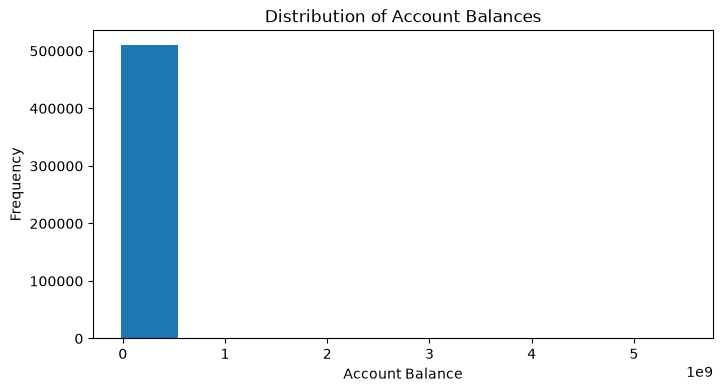

In [40]:
plt.figure(figsize=(8,4))

plt.hist(df["Account_Balance"], bins=10)

plt.title("Distribution of Account Balances")
plt.xlabel("Account Balance")
plt.ylabel("Frequency")

plt.show()

# 5. Statistical Summary

# 6. Data Dictionary

# 7. Initial Data Quality Observations

# 8. Summary of Findings